In [ ]:
import pandas as pd
import seaborn as sns
#pip install altair, pip install vega
import altair as alt
import matplotlib.pyplot as plt

In [84]:
df = pd.read_csv("../data/processed/cleaned_imputed_anime.csv", index_col=0)
df

,anime_id,name,genre,type,episodes,rating,members,themes,demographics,producers,studios,source,duration(mins),popularity,favorites
0,17467.0,Otoko Ippiki Gaki Daishou,"Action, Drama, Shounen",TV,156.0,7.200000,158.000000,Delinquents,Shounen,AT-X,Tokyo TV Douga,Manga,10.000000,12711.000000,2.000000
1,37007.0,Unknown,Unknown,Unknown,0.0,6.208692,3486.114429,"Combat Sports, School",Shounen,"Nihon Ad Systems, Pony Canyon, Shueisha, BS11,...",Gonzo,Manga,23.000000,1923.000000,357.000000
2,5702.0,Sora wo Miageru Shoujo no Hitomi ni Utsuru Sekai,"Action, Fantasy, Magic, Romance, Super Power",TV,9.0,7.270000,24799.000000,Super Power,Unknown,Unknown,Kyoto Animation,Original,24.000000,3759.000000,140.000000
3,26147.0,Nagasaki no Kouma,"Historical, Kids",Movie,1.0,7.330000,50.000000,Unknown,Unknown,Unknown,Unknown,Unknown,34.878176,10448.067844,34.494473
4,22247.0,Azumi Mamma★Mia,"Comedy, Kids",TV,60.0,5.600000,101.000000,Unknown,Unknown,Unknown,Unknown,Unknown,12.070050,15182.016412,2.549512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17684,1862.0,Strike Witches OVA,"Action, Ecchi, Magic, Military, Sci-Fi",OVA,1.0,6.290000,18236.000000,Military,Unknown,Rakuonsha,Gonzo,Original,8.000000,4689.000000,22.000000
17685,56746.0,Unknown,Unknown,Unknown,0.0,5.327455,197.398998,Idols (Male),Unknown,Happy Elements,DandeLion Animation Studio,Game,11.000000,12621.000000,19.000000
17686,26099.0,Hidamari no Ie,"Drama, Kids",OVA,1.0,7.000000,65.000000,Unknown,Unknown,Unknown,Unknown,Unknown,51.501941,12791.842565,1.892319
17687,22675.0,Peeping Life: Gekijou Original-ban,"Comedy, Slice of Life",Movie,5.0,4.670000,161.000000,Unknown,Unknown,Unknown,CoMix Wave Films,Original,1.000000,16510.000000,0.000000


In [85]:
df.describe()

,anime_id,episodes,rating,members,duration(mins),popularity,favorites
count,17689.000000,17689.000000,17689.000000,1.768900e+04,17689.000000,17689.000000,1.768900e+04
mean,23768.609927,8.367969,6.412525,1.322420e+04,31.095552,9001.242682,7.125272e+02
std,18096.922006,38.959317,0.960834,4.650487e+04,33.864297,5247.199351,5.772802e+03
min,1.000000,0.000000,1.670000,5.000000e+00,1.000000,1.000000,-1.136868e-13
25%,6018.000000,0.000000,5.800000,1.690000e+02,14.000000,4504.000000,2.000000e+00
50%,23031.000000,1.000000,6.460000,1.120000e+03,23.831254,9016.000000,1.100000e+01
75%,37293.000000,4.000000,7.070000,4.772000e+03,29.000000,13269.000000,8.312190e+01
max,62422.000000,1818.000000,10.000000,1.013917e+06,248.000000,22255.000000,2.434860e+05


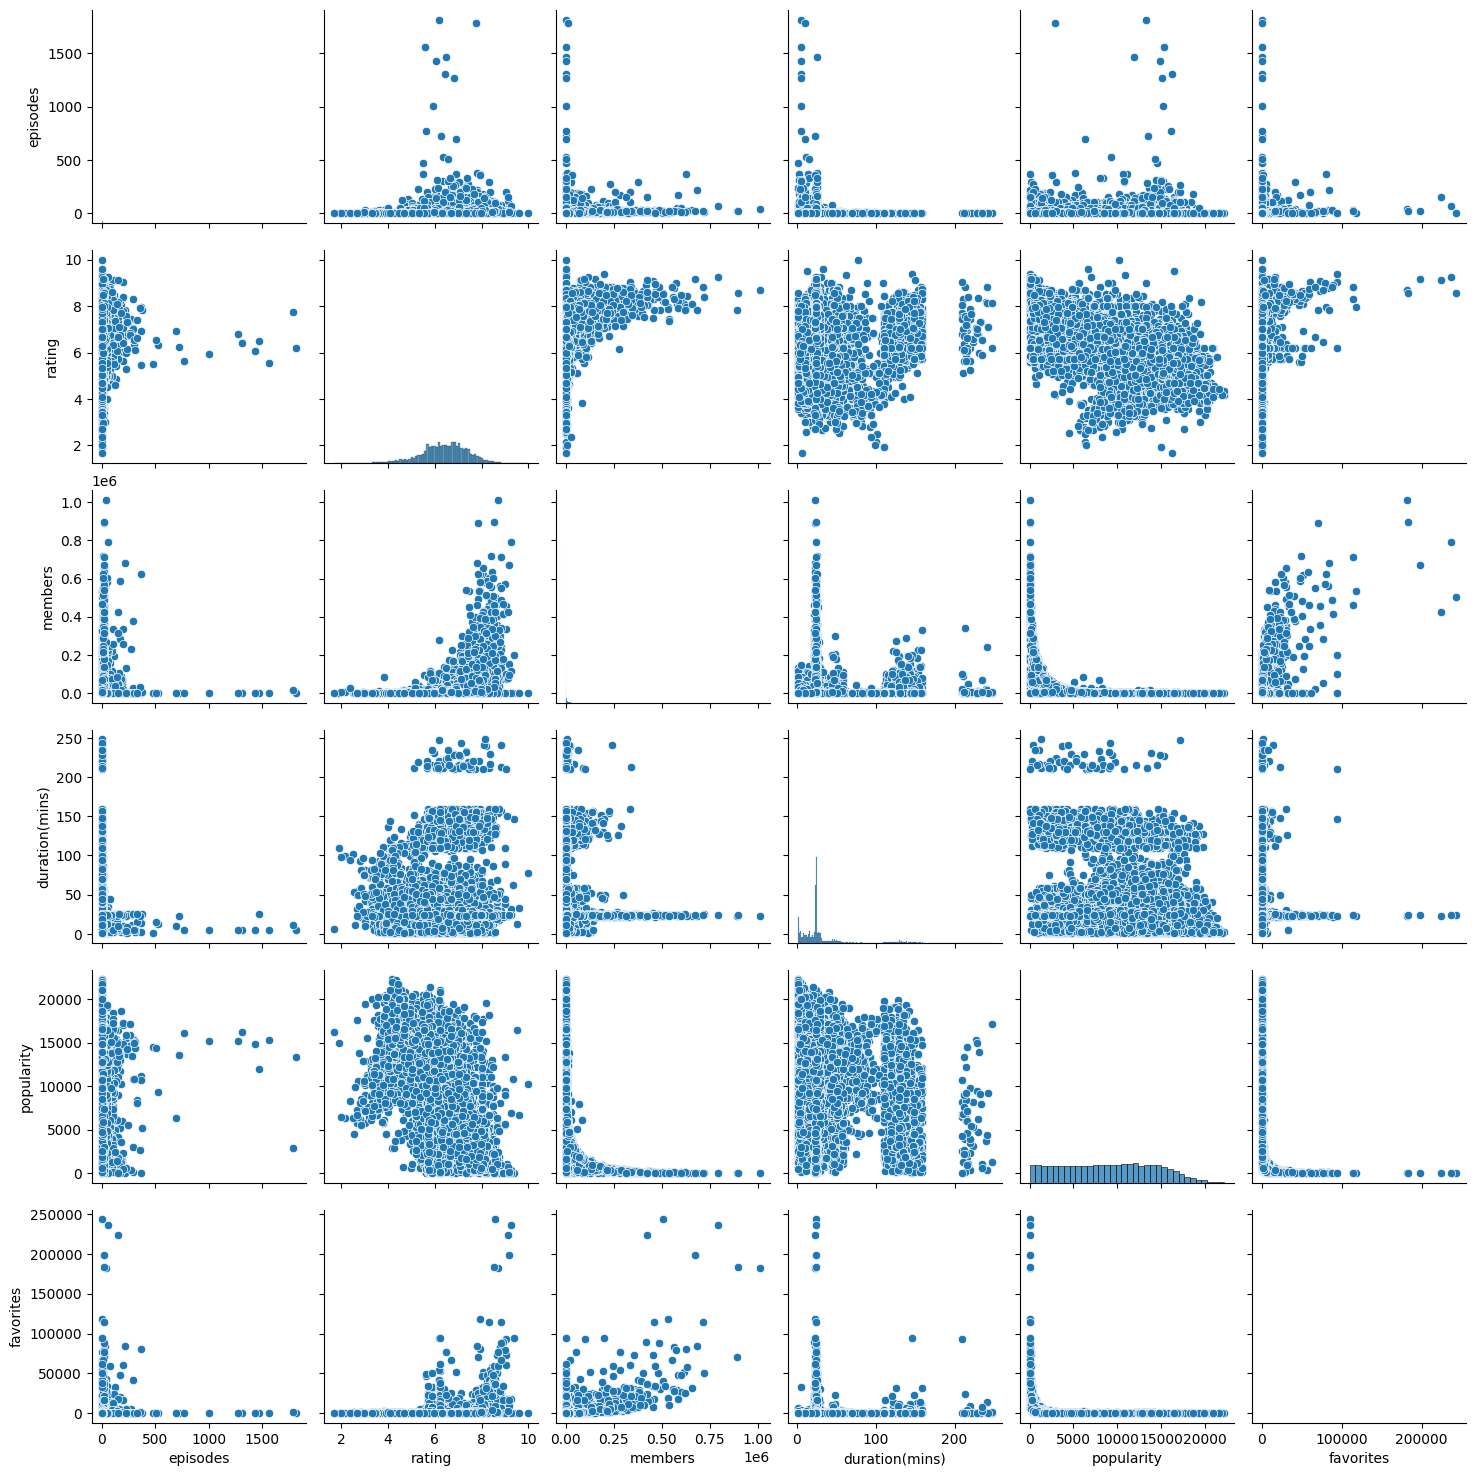

In [24]:
vars_to_compare = ["episodes", "rating", "members", "duration(mins)", "popularity", "favorites"]
pairwise = sns.pairplot(df, vars=vars_to_compare)

<Axes: >

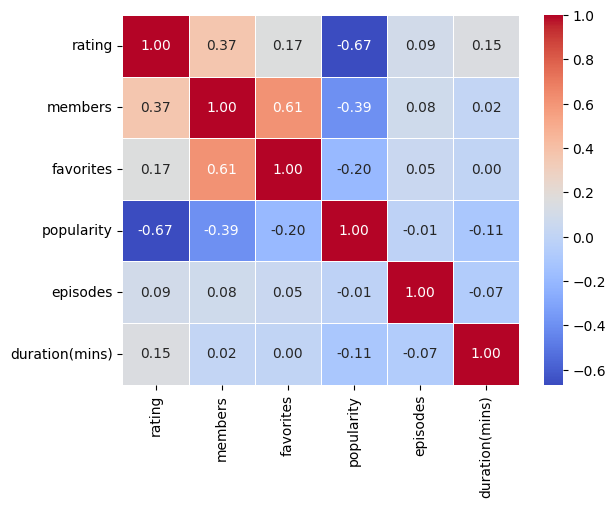

In [83]:
numeric_cols = ["rating", "members", "favorites", "popularity", "episodes", "duration(mins)"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=.6, cmap='coolwarm')

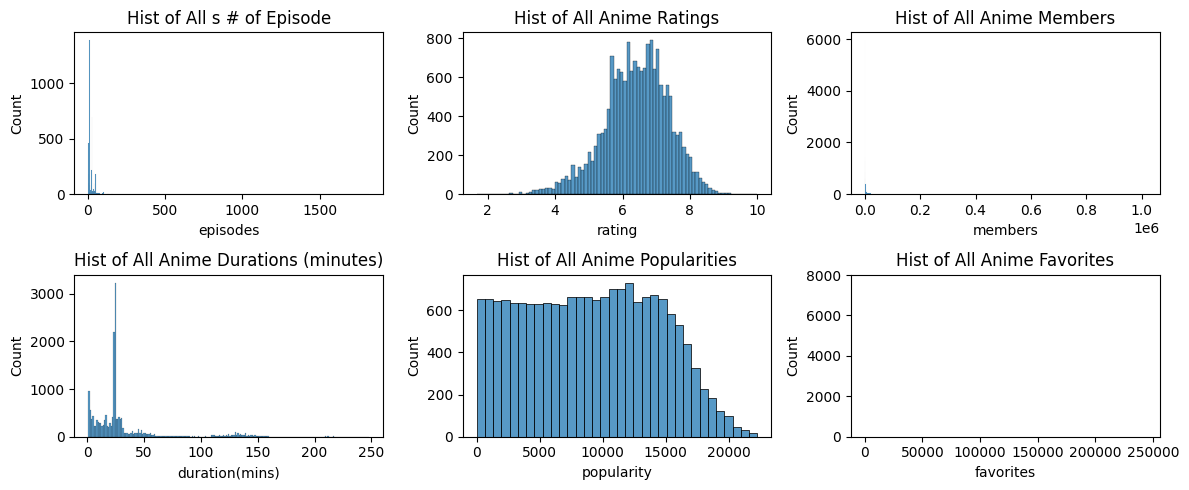

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(12, 5))

epdist = sns.histplot(df[df["episodes"]>4], x="episodes", ax=axes[0, 0])
epdist.set_title("Hist of All s # of Episode")

ratdist = sns.histplot(df, x="rating", ax=axes[0, 1])
ratdist.set_title("Hist of All Anime Ratings")

memdist = sns.histplot(df, x="members", ax=axes[0, 2])
memdist.set_title("Hist of All Anime Members")

popdist = sns.histplot(df, x="popularity", ax=axes[1, 1])
popdist.set_title("Hist of All Anime Popularities")

durdist = sns.histplot(df, x="duration(mins)", ax=axes[1, 0])
durdist.set_title("Hist of All Anime Durations (minutes)")

favdist = sns.histplot(df, x="favorites", ax=axes[1, 2])
favdist.set_title("Hist of All Anime Favorites")

plt.tight_layout()
plt.show()

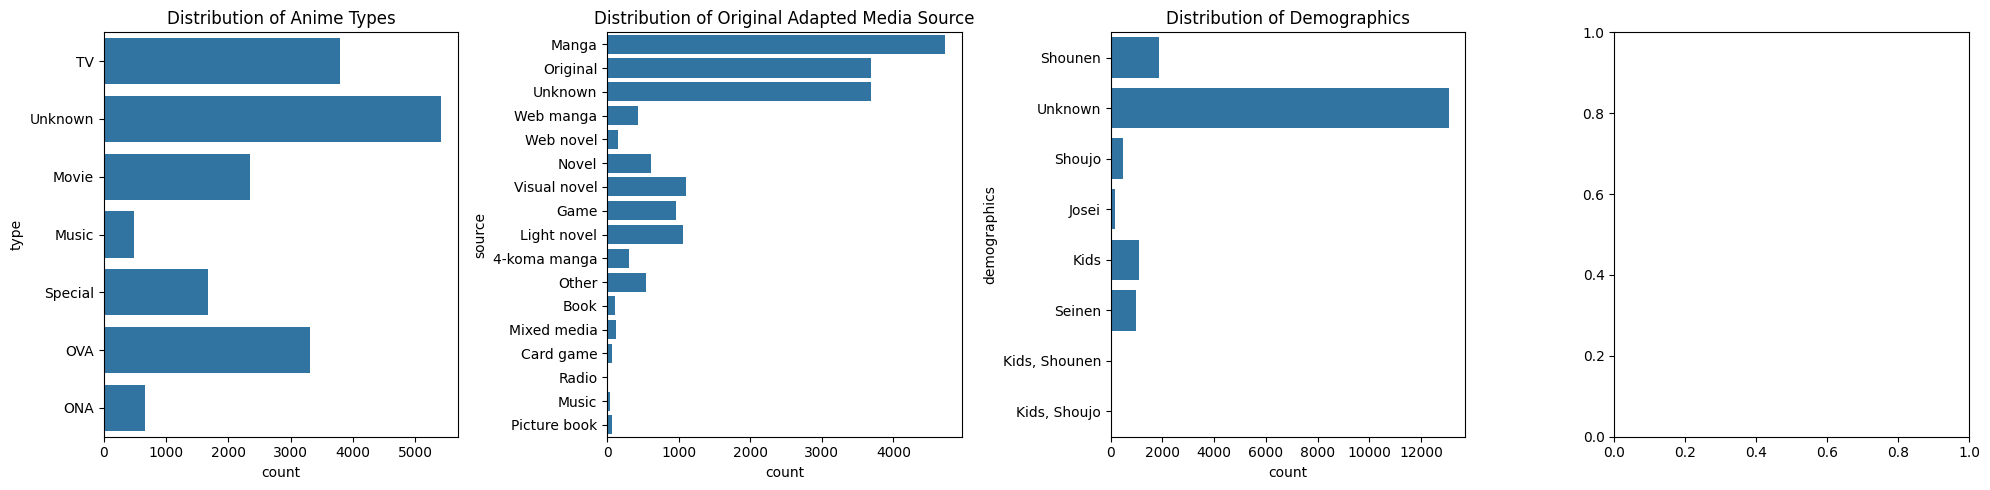

In [62]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.countplot(df, y="type", ax=axes[0]).set_title("Distribution of Anime Types")
sns.countplot(df, y="source", ax=axes[1]).set_title("Distribution of Original Adapted Media Source")
sns.countplot(df, y="demographics", ax=axes[2]).set_title("Distribution of Demographics")
plt.tight_layout()
plt.show()

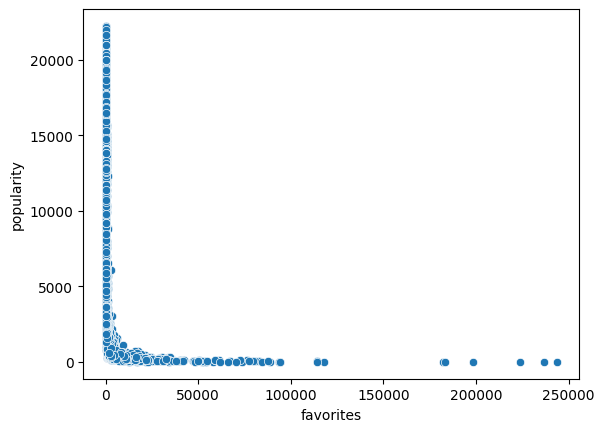

In [21]:
popscatter = sns.scatterplot(df, x="favorites", y="popularity")

[np.int64(1882), np.int64(13070), np.int64(463), np.int64(151), np.int64(1078), np.int64(991), np.int64(52), np.int64(2)]


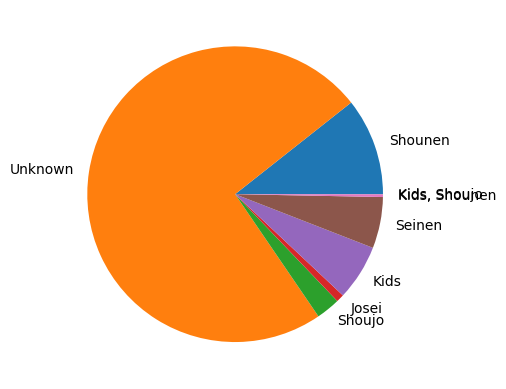

In [ ]:
demographicscounts = []
demographicnames = []
for demographic in df["demographics"].unique():
    demographicscounts.append(df[df["demographics"]==demographic]["demographics"].count())
    demographicnames.append(demographic)
print(demographicscounts)
demos = plt.pie(demographicscounts, labels = demographicnames)
demos
plt.show()

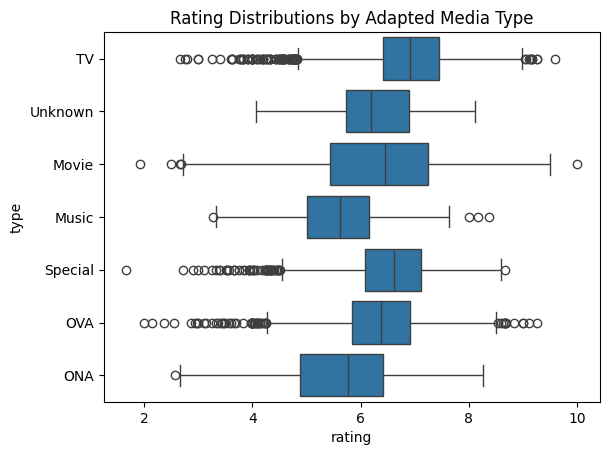

In [65]:
typevsrating = sns.boxplot(df, x="rating", y="type").set_title("Rating Distributions by Adapted Media Type")

In [128]:

alt.data_transformers.disable_max_rows()

brush = alt.selection_interval(encodings=["x"])

line = (alt.Chart(df).mark_line().encode(
        x=alt.Y("rating:Q", title="Rating"),
        color=alt.condition(brush, alt.value("steelblue"), alt.value("lightgray"))
    ).add_params(brush).properties(width=600, height=200, title="Select Range of Ratings to Display")
)


types = df["type"].unique().tolist()
demographics = df["demographics"].unique().tolist()
sources = df["source"].unique().tolist()


type_pie = (alt.Chart(df).mark_arc().encode(
        theta="count():Q",
        color=alt.Color(
            "type:N",
            title="Type",
            scale=alt.Scale(domain=types, scheme="set1")
        ),
        tooltip=["type", "count()"]
    ).transform_filter(brush).properties(width=250, height=250, title="Counts of Type")
)


demo_pie = (alt.Chart(df).mark_arc().encode(
        theta="count():Q",
        color=alt.Color(
            "demographics:N",
            title="Demographics",
            scale=alt.Scale(domain=demographics, scheme="set2")
        ),
        tooltip=["demographics", "count()"]
    ).transform_filter(brush).properties(width=250, height=250, title="Counts of Demographics")
)

source_pie = (alt.Chart(df).mark_arc().encode(
        theta="count():Q",
        color=alt.Color(
            "source:N",
            title="Source",
            scale=alt.Scale(domain=sources, scheme="tableau10"),
            legend=alt.Legend(orient="right")
        ),
        tooltip=["source", "count()"]
    ).transform_filter(brush).properties(width=250, height=250, title="Counts of Source")
)


layout = line & (type_pie | demo_pie | source_pie).resolve_scale(color="independent")
layout


alt.VConcatChart(...)